In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [11]:
df = pd.read_csv("exoplanet_data.csv", comment="#")
print("Shape of the dataset:", df.shape)
# There is 567 rows and 92 columns
print("All column titles:")
print(df.columns.tolist())
unknown_columns = [
    "sy_pnum",   
    "pl_controv_flag", 
    "pl_radeerr1",   
    "pl_insol",   
    "sy_gaiamag" 
]
print("5 column titles I don't understand:")
print(unknown_columns)

Shape of the dataset: (567, 92)
All column titles:
['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_m

In [ ]:
# Table Label: Planet Name  
# Database Column Name: pl_name  
# Description: “Planet name most commonly used in the literature.” 
# What I think it means: The standard name given to the exoplanet (for example “Kepler-22 b”), used so researchers refer to the same object.  

# Table Label: Host Name  
# Database Column Name: hostname  
# Description: “Stellar name most commonly used in the literature.” 
# What I think it means: The name of the star around which the exoplanet orbits — basically the “parent” star of the planet.  

# Table Label: Discovery Method  
# Database Column Name: discoverymethod  
# Description: (From NASA Exoplanet Archive columns) The method by which the planet was discovered (e.g., "Transit", "Radial Velocity"). :contentReference[oaicite:2]{index=2}  
# What I think it means: How astronomers found the planet — such as noticing dips in starlight (transit) or the star wobbling (radial velocity).  

# Table Label: Spectral Type  
# Database Column Name: st_spectype  
# Description: “Stellar spectral type of the host star.”
# What I think it means: A classification of the host star based on its temperature and characteristics (like G2V for the Sun) — gives an idea of the star’s properties.  

# Table Label: Equilibrium Temperature [K]  
# Database Column Name: pl_eqt  
# Description: “Equilibrium Temperature [K] — The equilibrium temperature of the planet as modeled by a black body heated only by its host star.” 
# What I think it means: The estimated temperature of the planet assuming it’s warmed by its star and radiates like a perfect absorber/emitter, ignoring atmosphere effects.  

# Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass]  
# Database Column Name: pl_bmassj  
# Description: “Planet Mass or Mass*sin(i) [Jupiter Mass] — Best planet mass estimate available, in order of preference: Mass, M·sin(i)/sin(i), or M·sin(i), depending on availability, and measured in Jupiter masses.”  
# What I think it means: The mass of the planet (or minimum mass if inclination unknown) measured in units of Jupiter’s mass — gives an idea of how big/heavy the planet is compared to Jupiter. 


In [13]:
columns_of_interest = [
    "pl_name",        # Planet Name
    "hostname",       # Host Name
    "discoverymethod",# Discovery Method
    "st_spectype",    # Spectral Type
    "pl_eqt",         # Equilibrium Temperature [K]
    "pl_bmassj"       # Planet Mass or Mass*sin(i) [Jupiter Mass]
]
small_df = df[columns_of_interest]
filtered_df = small_df.dropna()
print("Shape of filtered dataset:", filtered_df.shape)
num_rows, num_cols = filtered_df.shape
print(f"There are {num_rows} rows and {num_cols} columns.")

print("\nFirst five rows:")

print(filtered_df.head())
print("\nLast five rows:")

print(filtered_df.tail())

print("\nColumn titles:")
print(filtered_df.columns.tolist())

Shape of filtered dataset: (67, 6)
There are 67 rows and 6 columns.

First five rows:
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000

Last five rows:
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
546   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
549   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
555   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
561       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
566  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310

Column titles:
['pl_name',

In [14]:
method_counts = filtered_df["discoverymethod"].value_counts()

print("Discovery methods and their counts:\n")
print(method_counts)

most_common = method_counts.idxmax()
least_common = method_counts.idxmin()

print(f"\nMost common discovery method: {most_common} ({method_counts.max()} planets)")
print(f"Least common discovery method: {least_common} ({method_counts.min()} planets)")

Discovery methods and their counts:

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

Most common discovery method: Transit (52 planets)
Least common discovery method: Imaging (2 planets)


In [ ]:
# Transit:
# The planet passes in front of its star, dimming the star's light slightly.
# This dip in brightness repeats regularly, revealing the planet's orbit.

# Radial Velocity:
# The star "wobbles" due to the planet’s gravity — we detect this from shifts in its light spectrum.

# Imaging:
# The planet is directly photographed using special telescopes that block the star’s light.

# Microlensing:
# A planet’s gravity bends and magnifies light from a distant star, revealing its presence.

# Astrometry:
# Measures small changes in a star’s position in the sky caused by orbiting planets.

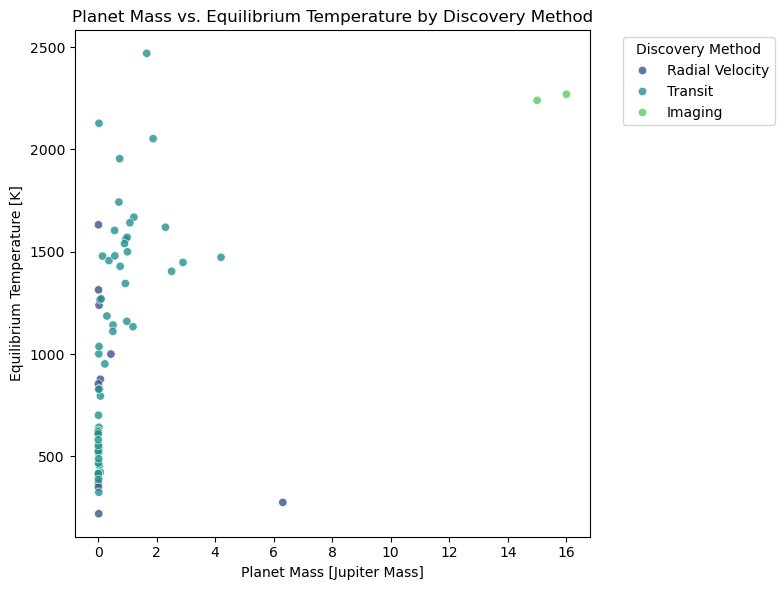

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=filtered_df,
    x="pl_bmassj", 
    y="pl_eqt", 
    hue="discoverymethod", 
    palette="viridis",
    alpha=0.8
)

plt.title("Planet Mass vs. Equilibrium Temperature by Discovery Method")
plt.xlabel("Planet Mass [Jupiter Mass]")
plt.ylabel("Equilibrium Temperature [K]")
plt.legend(title="Discovery Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

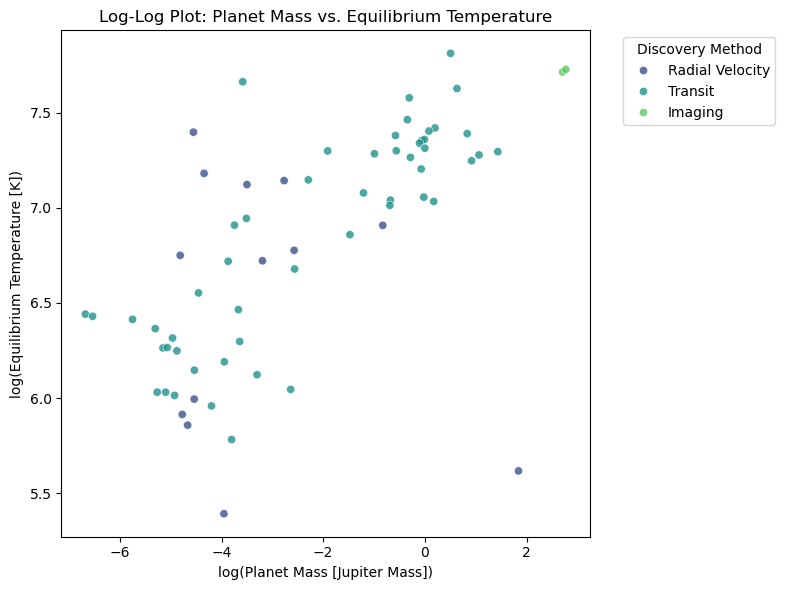

In [18]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=filtered_df,
    x=np.log(filtered_df["pl_bmassj"]),
    y=np.log(filtered_df["pl_eqt"]),
    hue="discoverymethod",
    palette="viridis",
    alpha=0.8
)

plt.title("Log-Log Plot: Planet Mass vs. Equilibrium Temperature")
plt.xlabel("log(Planet Mass [Jupiter Mass])")
plt.ylabel("log(Equilibrium Temperature [K])")
plt.legend(title="Discovery Method", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
# Exoplanets found by the imaging method are more likely to be massive according to the plot.
massive_planets = filtered_df[filtered_df["pl_bmassj"] > 5]
coldest_massive = massive_planets.loc[massive_planets["pl_eqt"].idxmin()]

print("Coldest planet with mass > 5 Jupiter masses:\n")
print(coldest_massive[["pl_name", "hostname", "pl_bmassj", "pl_eqt", "discoverymethod"]])

Coldest planet with mass > 5 Jupiter masses:

pl_name                eps Ind A b
hostname                 eps Ind A
pl_bmassj                     6.31
pl_eqt                       275.0
discoverymethod    Radial Velocity
Name: 566, dtype: object


In [20]:
print("Full data for the coldest planet with mass > 5 Jupiter masses:\n")
print(coldest_massive)
planet_name = coldest_massive["pl_name"]
planet_index = coldest_massive.name  # row index
planet_eqt = coldest_massive["pl_eqt"]
planet_mass = coldest_massive["pl_bmassj"]
host_star = coldest_massive["st_spectype"]

print(f"\nPlanet Name: {planet_name}")
print(f"Index in DataFrame: {planet_index}")
print(f"Equilibrium Temperature: {planet_eqt:.2f} K")
print(f"Mass: {planet_mass:.2f} Jupiter Masses")
print(f"Host Star Spectral Type: {host_star}")

# Determine if it’s sun-like
if isinstance(host_star, str) and host_star.startswith("G"):
    print("It orbits a Sun-like star (G-type).")
else:
    print("It does NOT orbit a Sun-like star.")

Full data for the coldest planet with mass > 5 Jupiter masses:

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 566, dtype: object

Planet Name: eps Ind A b
Index in DataFrame: 566
Equilibrium Temperature: 275.00 K
Mass: 6.31 Jupiter Masses
Host Star Spectral Type: K5 V
It does NOT orbit a Sun-like star.


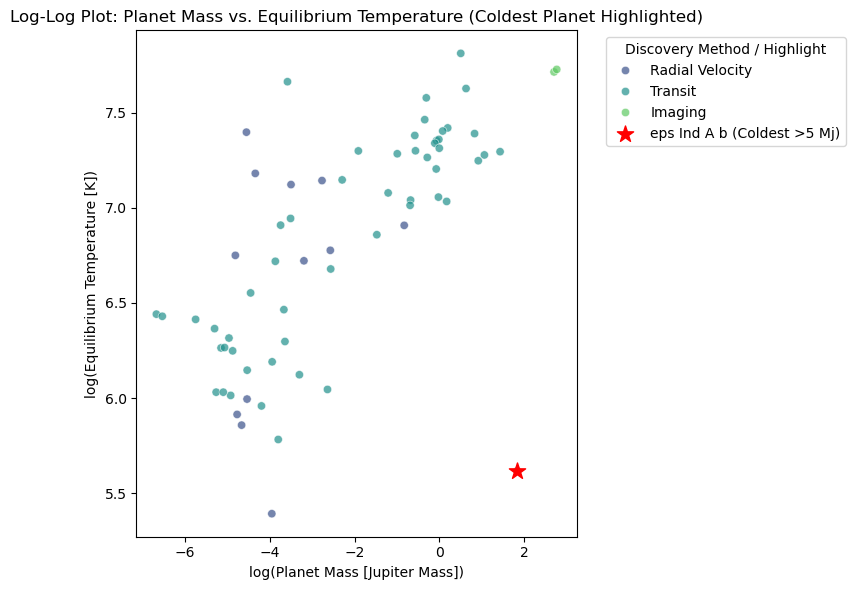

In [21]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=filtered_df,
    x=np.log(filtered_df["pl_bmassj"]),
    y=np.log(filtered_df["pl_eqt"]),
    hue="discoverymethod",
    palette="viridis",
    alpha=0.7
)
plt.scatter(
    np.log(coldest_massive["pl_bmassj"]),
    np.log(coldest_massive["pl_eqt"]),
    color="red",
    s=150,            # make it larger
    marker="*",       # star marker for emphasis
    label=f"{coldest_massive['pl_name']} (Coldest >5 Mj)"
)
plt.title("Log-Log Plot: Planet Mass vs. Equilibrium Temperature (Coldest Planet Highlighted)")
plt.xlabel("log(Planet Mass [Jupiter Mass])")
plt.ylabel("log(Equilibrium Temperature [K])")
plt.legend(title="Discovery Method / Highlight", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# The title is "A temperate super-Jupiter imaged with JWST in the mid-infrared"
# Astronomers have only taken pictures of about 25 planets outside our solar system so far, and almost all of them are very young — less than 100 million years old. Eps Ind Ais a much older, Sun-like star. A heavy planet is seen to be tugging on the star and new images from the JWST have actually captured this planet. It’s a giant exoplanet with a temperature around 275 K. The data show that this is the only big planet orbiting Epsilon Indi A, so astronomers call it Epsilon Indi Ab, even though its orbit is quite different from what earlier studies predicted.
# My answer does match the exoplanet.
# It is the only giant planet in the system and has a high carbon to oxygen ratio, and its temperature is consistent with previous theoretical models that scientists made but were not able to test at this scale.
# The mass does match the plot one, the equilibrium temperature does not really match. This can be because the JWST measured the planets infrared light directly, while the data from 2019 was based on the distance from the star and its brightness.